In [1]:
import os 
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append("/home/abharadwaj1/thesis/utils")
sys.path.append("/home/abharadwaj1/thesis/5_vitrification/utils")
from video_utils import get_specific_frame, detect_surface_level, detect_time_of_grid_arrival_from_kymograph

In [2]:
def get_line_intensities(video_path, x_pixel, y_top, y_bottom, start_frame, end_frame):
    line_intensities = []
    cap = cv2.VideoCapture(video_path)
    for frame_number in range(start_frame, end_frame + 1):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
        ret, frame = cap.read()
        if not ret:
            print(f"Failed to read frame {frame_number}")
            continue
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        line_intensity = gray_frame[y_top:y_bottom, x_pixel]
        line_intensities.append(line_intensity)
    cap.release()
    return np.array(line_intensities)

def detect_edge_from_kymograph(kymograph):
    """
    Detect the edges of the kymograph based on a Canny edge detection algorithm.
    """
    import cv2
    from scipy.ndimage import uniform_filter

    # Convert kymograph to grayscale if it is not already
    if len(kymograph.shape) == 3:
        kymograph_gray = cv2.cvtColor(kymograph, cv2.COLOR_BGR2GRAY)
    else:
        kymograph_gray = kymograph
    
    kymograph_filtered = uniform_filter(kymograph_gray, size=(6, 6), mode='nearest')
    kymograph_normalised = (kymograph_filtered - kymograph_filtered.min()) / (kymograph_filtered.max() - kymograph_filtered.min())
    kymograph_binarised = (kymograph_normalised < 0.5).astype(np.uint8)  # Binarise the kymograph
    # Apply Canny edge detection

    edges = cv2.Canny(kymograph_binarised, 0.2, 0.8)
    # return normalised values for edges 
    edges_normalised = edges / edges.max()
    edges_binarised = (edges_normalised > 0.5).astype(int)  # Binarise the edges
    return edges_binarised


In [27]:
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/analyse_cavity_closing/autogrid/autogrid_front_vid_2025-07-21_19-28-45.mp4"
video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/analyse_cavity_closing/autogrid/autogrid_side_vid_2025-07-21_19-25-39.mp4"

#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/thickness_analysis/thickness_900/vid_2025-08-01_17-50-12.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/thickness_analysis/thickness_300/vid_2025-08-01_17-20-56.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/thickness_analysis/thickness_100/vid_2025-08-01_17-38-02.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/thickness_analysis/thickness_25/vid_2025-08-01_17-44-50.mp4"

#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/analyse_cavity_closing/cryoemgrid/vid_2025-07-15_13-40-19.mp4"
output_folder = "/home/abharadwaj1/thesis/data_archive/figures_output/5_vitrification/kymographs"
cap = cv2.VideoCapture(video_path)

# Show the first frame
ret, frame = cap.read()
if not ret:
    print("Failed to read video")
    cap.release()
    exit()

Length of kymograph in frames: 54
Surface level detected at: 130.00 pixels
Depth of 2.4 mm corresponds to pixel position: 272


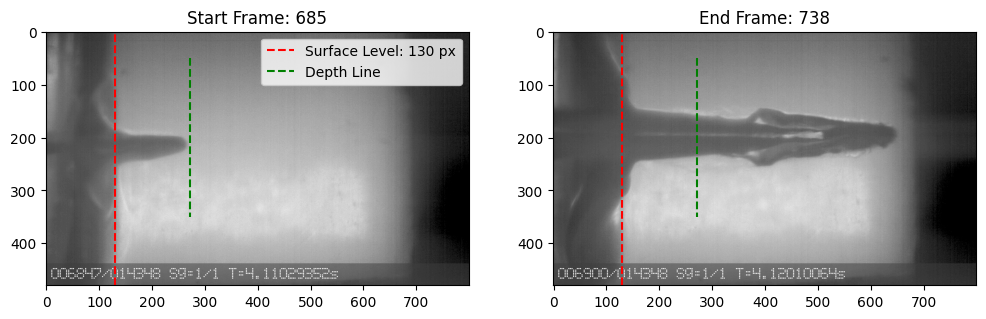

In [29]:
apix_lateral = 20.4e-6  # microns per pixel
lensing_effect_correction = 149/123 
apix_depth = apix_lateral / lensing_effect_correction
#apix=18.3e-6
frame_rate = 5406 # frames per second
sampling_time = 1 / frame_rate  # seconds per frame

start_frame_number = 685#703# 685
length_of_kymograph_ms = 10  # milliseconds
length_of_kymograph = int(length_of_kymograph_ms * 1e-3 / sampling_time)  # convert ms to frames
print(f"Length of kymograph in frames: {length_of_kymograph}")
x_depth_mm = 2.4 # depth in mm counted from bottom of surface level (so add 1 later to get depth from mid-point of meniscus)
y_top_pixel = 50
y_bottom_pixel = 350

# Calculate the pixel position for the depth in microns

end_frame_number = start_frame_number + length_of_kymograph - 1

first_frame = get_specific_frame(video_path, 0)
start_frame = get_specific_frame(video_path, start_frame_number)
end_frame = get_specific_frame(video_path, end_frame_number)

surface_level = detect_surface_level(first_frame)[0]
print(f"Surface level detected at: {surface_level:.2f} pixels")
x_depth_pixel = surface_level + int(x_depth_mm * 1e-3 / apix_depth)
print(f"Depth of {x_depth_mm} mm corresponds to pixel position: {x_depth_pixel}")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(start_frame, cmap='gray')
ax[0].set_title(f"Start Frame: {start_frame_number}")
ax[0].axvline(x=surface_level, color='r', linestyle='--', label=f'Surface Level: {surface_level:.0f} px')
ax[0].plot([x_depth_pixel, x_depth_pixel], [y_top_pixel, y_bottom_pixel], color='g', linestyle='--', label='Depth Line')
ax[1].imshow(end_frame, cmap='gray')
ax[1].set_title(f"End Frame: {end_frame_number}")
ax[1].axvline(x=surface_level, color='r', linestyle='--', label='Surface Level')
ax[1].plot([x_depth_pixel, x_depth_pixel], [y_top_pixel, y_bottom_pixel], color='g', linestyle='--', label='Depth Line')
ax[0].legend()

plt.show()



In [30]:
kymograph = get_line_intensities(video_path, x_depth_pixel, y_top_pixel, y_bottom_pixel, start_frame_number, end_frame_number)
kymograph = np.array(kymograph).transpose()



Kymograph saved to: /home/abharadwaj1/thesis/data_archive/figures_output/5_vitrification/kymographs/thickness_kymograph_depth_2.4mm_0685_to_0738_autogrid_side_vid_2025-07-21_19-25-39.mp4.pdf


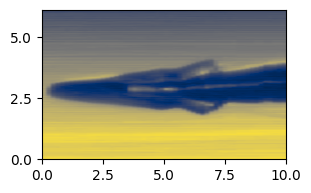

In [31]:
x_start_ms = 0  # Starting point in mm
x_end_ms = length_of_kymograph * sampling_time * 1e3  # Convert to mm
y_start_mm = 0 
y_end_mm = (y_bottom_pixel - y_top_pixel) * apix_lateral * 1e3  # Convert to mm

figsize_mm = (80, 50)
fig, ax = plt.subplots(figsize=(figsize_mm[0] / 25.4, figsize_mm[1] / 25.4))  # Convert mm to inches for matplotlib
ax.imshow(kymograph, cmap='cividis', aspect=1, extent=[x_start_ms, x_end_ms, y_start_mm, y_end_mm])
ax.set_xticks([0, 2.5, 5, 7.5, 10])
ax.set_yticks([0, 2.5, 5])
save_path = os.path.join(output_folder, f"thickness_kymograph_depth_{x_depth_mm:.1f}mm_{start_frame_number:04d}_to_{end_frame_number:04d}_{os.path.basename(video_path)}.pdf")
plt.savefig(save_path, bbox_inches='tight', dpi=600)
print(f"Kymograph saved to: {save_path}")


In [32]:
# save kymograph as a numpy array
#kymograph_save_path = os.path.join(output_folder, f"kymograph_depth_{x_depth_mm:.1f}mm_{start_frame_number:04d}_to_{end_frame_number:04d}_{os.path.basename(video_path)}.npy")
#np.save(kymograph_save_path, kymograph)

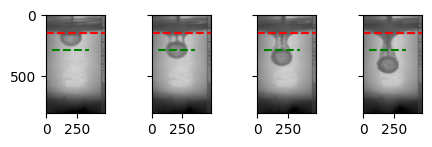

In [57]:
frame_numbers_to_plot = [702, 715, 723, 731]
frames = [get_specific_frame(video_path, fn) for fn in frame_numbers_to_plot]
figsize_mm = (120, 40)
fig, ax = plt.subplots(1, len(frames), figsize=(figsize_mm[0] / 25.4, figsize_mm[1] / 25.4), sharey=True)  # Convert mm to inches for matplotlib
for i, frame in enumerate(frames):
    ax[i].imshow(frame.transpose(), cmap='gray')
    #ax[i].set_title(f"Frame {frame_numbers_to_plot[i]}")
    ax[i].axhline(y=surface_level, color='r', linestyle='--', label=f'Surface Level: {surface_level:.0f} px')
    ax[i].plot([y_top_pixel, y_bottom_pixel], [x_depth_pixel, x_depth_pixel], color='g', linestyle='--', label='Depth Line')
    #ax[i].legend()
plt.tight_layout()
save_path = os.path.join(output_folder, f"frames_depth_{x_depth_mm:.1f}mm_{start_frame_number:04d}_to_{end_frame_number:04d}_{os.path.basename(video_path)}.pdf")
plt.savefig(save_path, bbox_inches='tight', dpi=600)


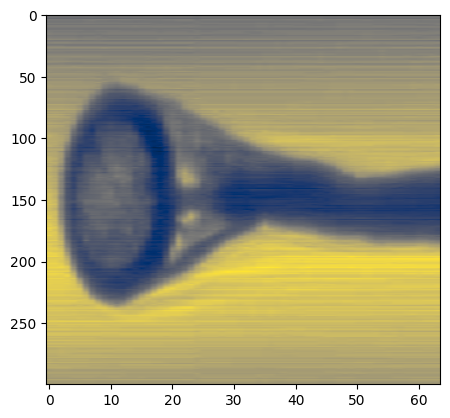

In [44]:
plt.imshow(kymograph, cmap='cividis', aspect=0.2)

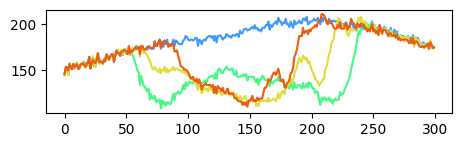

In [56]:
# plot corresponding line intensities 
import seaborn as sns
figsize_mm = (120, 40)
colors = sns.color_palette("turbo", len(frame_numbers_to_plot))
fig, ax = plt.subplots(1, 1, figsize=(figsize_mm[0] / 25.4, figsize_mm[1] / 25.4), sharey=True)
frames_shifted = [x - start_frame_number for x in frame_numbers_to_plot]
frames_shifted[0] = 0
for i, frame in enumerate(frames_shifted):
    ax.plot(kymograph[:, frame], color=colors[i])
#ax.set_xlabel("Pixel Position")
#ax.set_ylabel("Intensity")
fig.tight_layout()
# Save the plot
save_path = os.path.join(output_folder, f"line_intensities_depth_{x_depth_mm:.1f}mm_{start_frame_number:04d}_to_{end_frame_number:04d}_{os.path.basename(video_path)}.pdf")
plt.savefig(save_path, bbox_inches='tight', dpi=600)


In [48]:
start_frame_number

703